CUSTOMER CHURN PREDICTION USING ANN

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\ayush\Downloads\credit_card_customer_churn.csv")
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [6]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [10]:
df = pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True,dtype = int)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = df.drop(columns = ['Exited'])
y = df['Exited']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [19]:
!pip install tensorflow
import tensorflow 


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.69.2 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-api-core 2.24.2 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.35.0 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.0 which is incompatible.
modal 1.4.2 requires protobuf!=4.24.0,<7.0,>=3.19, but you have protobuf 7.35.0 which is incompatible.
proto-plus 1.26.1 requires protobuf<7.0.0,>=3.19.0, but you have protobuf 7.35.0 which is i

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 1.3/350.8 MB 9.5 MB/s eta 0:00:37
   ---------------------------------------- 3.7/350.8 MB 10.4 MB/s eta 0:00:34
    --------------------------------------- 5.8/350.8 MB 10.7 MB/s eta 0:00:33
    --------------------------------------- 8.1/350.8 MB 11.2 MB/s eta 0:00:31
   - -------------------------------------- 9.4/350.8 MB 10.0 MB/s eta 0:00:35
   - -------------------------------------- 11.3/350.8 MB 9.4 MB/s eta 0:00:37
   - -------------------------------------- 13.6/350.8 MB 9.5 MB/s eta 0:00:36
   - -------------------------------------- 16.0/350.8 MB 9.6 MB/s eta 0:00:35
   -- ------------------------------------- 17.8/350.8 MB 9.5 MB/s eta 0:00:35
   -- ------------------------------------- 19.7/350.8 MB 9.4 MB/s eta 0:00:36
   -- ------------------------------------- 22.0/350.8 MB 9.6 MB/s eta 0:00:35
   -- ------------------------------------- 24.4/350.8 MB 9.6

In [24]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [38]:
model =  Sequential()

model.add(Dense(3,activation = 'relu',input_dim = 11))
model.add(Dense(1,activation = 'sigmoid'))

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])
hist = model.fit(x_train_scaled,y_train,epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8560 - loss: 0.3541
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3536
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.3537
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - loss: 0.3533
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8560 - loss: 0.3531
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.3533
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8583 - loss: 0.3525
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8554 - loss: 0.3527
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8572 - loss: 0.3527
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3524
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8564 - loss: 0.3523
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

In [45]:
accuracy = model.evaluate(x_test_scaled,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3427 


In [42]:
model.layers[1].get_weights()

[array([[ 1.6819707],
        [-1.4300594],
        [-1.4616097]], dtype=float32),
 array([0.91653925], dtype=float32)]

In [43]:
ab = model.predict(x_test_scaled)
y_pred = np.where(ab > 0.5, 1, 0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [47]:
import matplotlib.pyplot as plt
hist.history

{'accuracy': [0.8560000061988831,
  0.856249988079071,
  0.8558750152587891,
  0.8556249737739563,
  0.8560000061988831,
  0.8558750152587891,
  0.8582500219345093,
  0.8553749918937683,
  0.8572499752044678,
  0.856249988079071,
  0.856374979019165,
  0.8565000295639038,
  0.8551250100135803,
  0.8572499752044678,
  0.8583750128746033,
  0.8556249737739563,
  0.8577499985694885,
  0.8565000295639038,
  0.8575000166893005,
  0.8575000166893005,
  0.859375,
  0.8581249713897705,
  0.8601250052452087,
  0.8572499752044678,
  0.859624981880188,
  0.859125018119812,
  0.859624981880188,
  0.8583750128746033,
  0.859749972820282,
  0.859375,
  0.8604999780654907,
  0.8586249947547913,
  0.8608750104904175,
  0.8588749766349792,
  0.859624981880188,
  0.8608750104904175,
  0.859375,
  0.859250009059906,
  0.859000027179718,
  0.8581249713897705,
  0.8576250076293945,
  0.8587499856948853,
  0.859375,
  0.8587499856948853,
  0.8582500219345093,
  0.8588749766349792,
  0.8610000014305115,
  0.

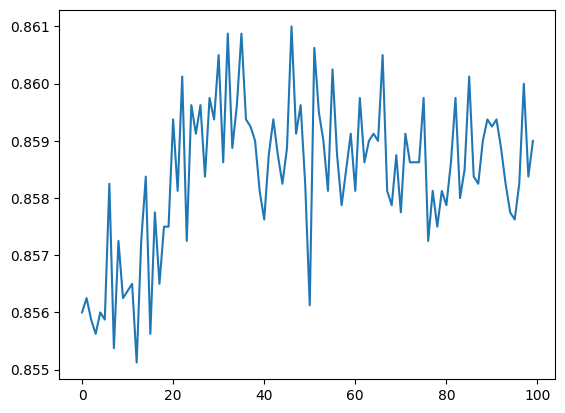

In [50]:
plt.plot(hist.history['accuracy'])

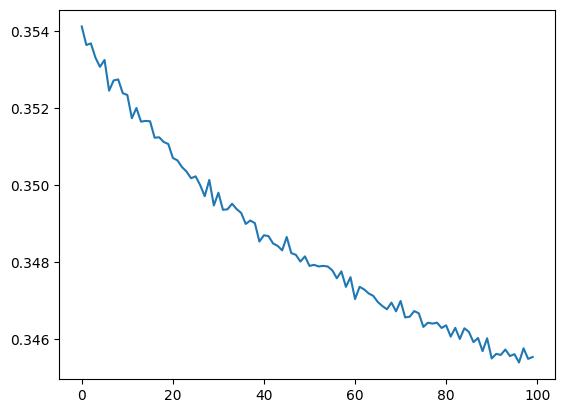

In [51]:
plt.plot(hist.history['loss'])